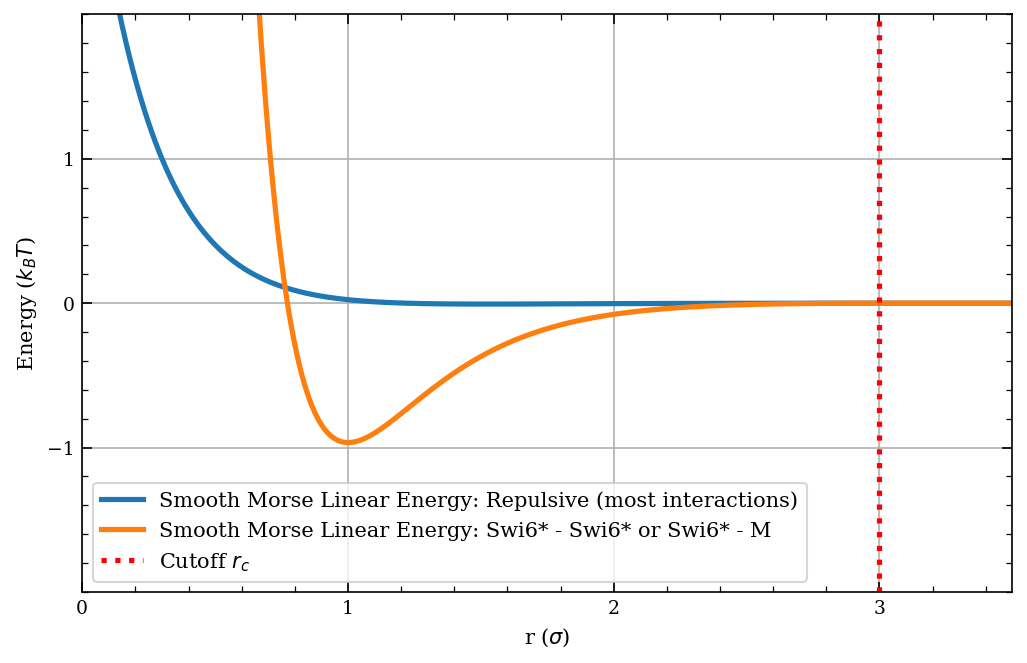

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family"         : "serif",
    "font.serif"          : ["DejaVu Serif", "Times New Roman", "serif"],
    "font.size"           : 7,
    "axes.labelsize"      : 7,
    "xtick.direction"     : "in", "ytick.direction"     : "in",
    "xtick.top"           : True,  "ytick.right"         : True,
    "xtick.minor.visible" : True,  "ytick.minor.visible" : True,
    "xtick.major.size"    : 5,     "ytick.major.size"    : 5,
    "xtick.minor.size"    : 3,     "ytick.minor.size"    : 3,
    "lines.linewidth"     : 1.5,   "figure.dpi"          : 150,
})
def morse_potential(r, D0, alpha, r0):
    return D0 * (np.exp(-2 * alpha * (r - r0)) - 2 * np.exp(-alpha * (r - r0)))

def smooth_linear_energy(r, D0, alpha, r0, rc):
    phi_rc = morse_potential(rc, D0, alpha, r0)
    dphi_rc = -2 * alpha * D0 * np.exp(-2 * alpha * (rc - r0)) + 2 * alpha * D0 * np.exp(-alpha * (rc - r0))
    E_r = np.where(r < rc, morse_potential(r, D0, alpha, r0) - phi_rc - (r - rc) * dphi_rc, 0)
    return E_r

# Parameters
rc = 3.0  # cutoff distance
interactions = {
    "Repulsive (most interactions)": (1e-2, 2.0, 1.5),
    "Swi6* - Swi6* or Swi6* - M": (1.0, 3.0, 1.0)
}

# Generate distance values
r_values = np.linspace(0.01, 3.5, 500)

# Plot Morse potentials
plt.figure(figsize=(8,5))
for label, (D0, alpha, r0) in interactions.items():
    phi_values = morse_potential(r_values, D0, alpha, r0)
    E_values = smooth_linear_energy(r_values, D0, alpha, r0, rc)
    plt.plot(r_values, E_values, linestyle='solid', label=f"Smooth Morse Linear Energy: {label}",lw=2.5)

plt.axvline(x=rc, color='red', linestyle='dotted', label="Cutoff $r_c$",lw=2.5)
plt.xlabel(r"r ($\sigma$)", fontsize = 10)
plt.ylim([-2,2])
plt.xticks([0,1,2,3], fontsize = 9)
plt.yticks([-1,0,1], fontsize = 9)
plt.xlim([0,3.5])
plt.ylabel("Energy ($k_BT$)", fontsize = 10)
plt.legend(fontsize = 10)
plt.grid()
plt.savefig("FigS1.pdf")
